In [75]:
import numpy as np
import matplotlib.pyplot as plt

from astropy.io import fits
from astropy.table import Table

import pandas as pd
import pyStarlet_master_2D1D as pys


from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

from matplotlib.colors import LogNorm
from scipy.ndimage import gaussian_filter1d

import torch

In [76]:
# DECLARE CONSTANTS

EVT_FILE = 'acisi_merged.fits'
XMIN = 4085
XMAX = 4120
YMIN = 4080
YMAX = 4120

EMIN = 2000
EMAX = 5500

BINX = 32
BINY = 32
BINE = 50

VERBOSE = False

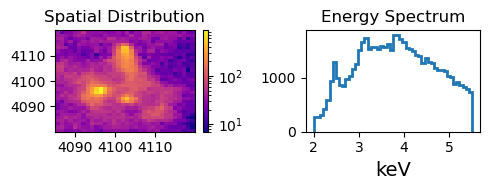

<Figure size 400x400 with 0 Axes>

<Figure size 400x400 with 0 Axes>

In [77]:

hdu = fits.open(EVT_FILE)
evt_data = hdu[1].data

cols = ['energy', 'x', 'y', 'ccd_id']
df = Table([evt_data[c] for c in cols], names=cols).to_pandas()



subset = df[(df['x'] > XMIN) & (df['x'] < XMAX) & \
            (df['y'] > YMIN) & (df['y'] < YMAX) & \
            (df['energy'] > EMIN) & (df['energy'] < EMAX)]

fig = plt.figure(figsize=(5, 2)) 
ax1 = fig.add_subplot(1, 2, 1)
h2d = ax1.hist2d(subset['x'], subset['y'], bins=(BINX, BINY), 
                 cmap='plasma', norm=LogNorm())
ax1.set_title('Spatial Distribution')
fig.colorbar(h2d[3], ax=ax1)

ax2 = fig.add_subplot(1, 2, 2)
ax2.hist(subset['energy']/1.e3, bins=BINE, histtype='step', lw=2)
ax2.set_xlabel('keV', size=14)
ax2.set_title('Energy Spectrum')

plt.tight_layout()
plt.show()
plt.figure(2, figsize=(4,4))

In [78]:
# DEFINE SPECTRAL CUBE (our base data that we try to match)
spectral_cube, _ = np.histogramdd(subset[['energy', 'x', 'y']].values, bins=(BINE, BINX, BINY))
spectral_cube_tensor = torch.tensor(spectral_cube, dtype=torch.float32)

if VERBOSE: print(spectral_cube.shape)

In [256]:
# transform into starlet space
NUM_LVL = 2
LVL_START = 1
starlet_cube = pys.Starlet_Forward3D(spectral_cube,J=4)[:,:,:,LVL_START:LVL_START+NUM_LVL]

# add starlet transform to subset
_, edges = np.histogramdd(subset[['energy', 'x', 'y']].values, bins=(BINE, BINX, BINY))

dims = ['energy', 'x', 'y']
indices = []
for i, col in enumerate(dims):
    # Find bin index (subtract 1 for 0-indexing)
    idx = np.digitize(subset[col].values, edges[i]) - 1
    # Clip to stay within cube boundaries
    idx = np.clip(idx, 0, starlet_cube.shape[i] - 1)
    indices.append(idx)
e_idx, x_idx, y_idx = indices

e_lvls = ['energy']

for lvl in range(NUM_LVL):
    subset[f'starlet_{lvl}'] = starlet_cube[e_idx, x_idx, y_idx, lvl]
    e_lvls.append(f'starlet_{lvl}')

/tmp/ipykernel_29224/422445689.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset[f'starlet_{lvl}'] = starlet_cube[e_idx, x_idx, y_idx, lvl]


## Gaussian Mixture Model Initialization ##

In [251]:
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler

std_scaler = StandardScaler()
scaled_df = std_scaler.fit_transform(subset[['x', 'y', 'energy']])

NCOMP = 3
gmm = GaussianMixture(
    n_components=NCOMP,
    covariance_type='full',   # most flexible; try 'diag' if you want faster
    random_state=0
)

gmm.fit(scaled_df)

,"n_components n_components: int, default=1The number of mixture components.",3
,"covariance_type covariance_type: {'full', 'tied', 'diag', 'spherical'}, default='full'String describing the type of covariance parameters to use.Must be one of:- 'full': each component has its own general covariance matrix.- 'tied': all components share the same general covariance matrix.- 'diag': each component has its own diagonal covariance matrix.- 'spherical': each component has its own single variance.For an example of using `covariance_type`, refer to:ref:`sphx_glr_auto_examples_mixture_plot_gmm_selection.py`.",'full'
,"tol tol: float, default=1e-3The convergence threshold. EM iterations will stop when thelower bound average gain is below this threshold.",0.001
,"reg_covar reg_covar: float, default=1e-6Non-negative regularization added to the diagonal of covariance.Allows to assure that the covariance matrices are all positive.",1e-06
,"max_iter max_iter: int, default=100The number of EM iterations to perform.",100
,"n_init n_init: int, default=1The number of initializations to perform. The best results are kept.",1
,"init_params init_params: {'kmeans', 'k-means++', 'random', 'random_from_data'}, default='kmeans'The method used to initialize the weights, the means and theprecisions.String must be one of:- 'kmeans' : responsibilities are initialized using kmeans.- 'k-means++' : use the k-means++ method to initialize.- 'random' : responsibilities are initialized randomly.- 'random_from_data' : initial means are randomly selected data points... versionchanged:: v1.1 `init_params` now accepts 'random_from_data' and 'k-means++' as initialization methods.",'kmeans'
,"weights_init weights_init: array-like of shape (n_components, ), default=NoneThe user-provided initial weights.If it is None, weights are initialized using the `init_params` method.",None
,"means_init means_init: array-like of shape (n_components, n_features), default=NoneThe user-provided initial means,If it is None, means are initialized using the `init_params` method.",None
,"precisions_init precisions_init: array-like, default=NoneThe user-provided initial precisions (inverse of the covariancematrices).If it is None, precisions are initialized using the 'init_params'method.The shape depends on 'covariance_type':: (n_components,) if 'spherical', (n_features, n_features) if 'tied', (n_components, n_features) if 'diag', (n_components, n_features, n_features) if 'full'",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to the method chosen to initialize theparameters (see `init_params`).In addition, it controls the generation of random samples from thefitted distribution (see the method `sample`).Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",0


In [252]:
probs = gmm.predict_proba(scaled_df)  # shape: (N_points, NCOMP)

if VERBOSE:
    print("Means (scaled):")
    print(gmm.means_)

    print("Covariances:")
    print(gmm.covariances_)

    print("BIC:", gmm.bic(scaled_df))
    print("AIC:", gmm.aic(scaled_df))

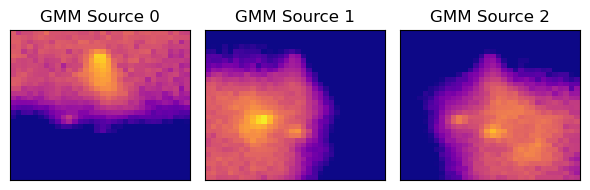

In [253]:
VMIN = 0.5
VMAX = 1e3

fig = plt.figure(figsize=(2 * NCOMP, 2))

for i in range(NCOMP):
    ax = plt.subplot(100 + 10 * NCOMP + i + 1)

    h = ax.hist2d(
        subset['x'],
        subset['y'],
        bins=(BINX, BINY),
        range=[[XMIN, XMAX], [YMIN, YMAX]],
        weights=probs[:, i],
        cmap='plasma',
        norm=LogNorm(vmin=VMIN, vmax=VMAX)
    )

    ax.set_title(f'GMM Source {i}')
    ax.set_xlim(XMIN, XMAX)
    ax.set_ylim(YMIN, YMAX)
    ax.xaxis.set_visible(False)
    ax.yaxis.set_visible(False)

plt.tight_layout()

In [191]:
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu') # use GPU

n_comp = 3
n_bands, nx_pixels, ny_pixels = spectral_cube_tensor.shape
x_range = (XMIN, XMAX)
y_range = (YMIN, YMAX)

## BLANKSKY ##

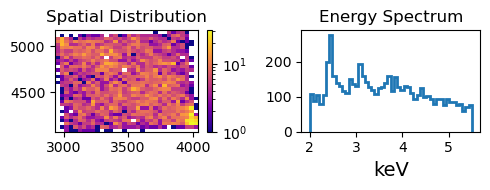

<Figure size 400x400 with 0 Axes>

<Figure size 400x400 with 0 Axes>

In [270]:
# Load in blank sky
BG_FILE = "6639_c0.fits"
hdul = fits.open(BG_FILE)
bg_data = hdul[1].data

cols = ['energy', 'x', 'y', 'ccd_id']

bg_df = Table([bg_data[c] for c in cols], names=cols).to_pandas()
bg_subset = bg_df[(bg_df['energy'] > EMIN) & (bg_df['energy'] < EMAX)]

fig = plt.figure(figsize=(5, 2)) 
ax1 = fig.add_subplot(1, 2, 1)
h2d = ax1.hist2d(bg_subset['x'], bg_subset['y'], bins=(BINX, BINY),
                 cmap='plasma', norm=LogNorm())
ax1.set_title('Spatial Distribution')
fig.colorbar(h2d[3], ax=ax1)

ax2 = fig.add_subplot(1, 2, 2)
ax2.hist(bg_subset['energy']/1.e3, bins=BINE, histtype='step', lw=2)
ax2.set_xlabel('keV', size=14)
ax2.set_title('Energy Spectrum')

plt.tight_layout()
plt.show()
plt.figure(2, figsize=(4,4))

In [271]:
# transform into starlet space
bg_cube, _ = np.histogramdd(bg_subset[['energy', 'x', 'y']].values, bins=(BINE, BINX, BINY))
starlet_bg = pys.Starlet_Forward3D(bg_cube, J=4)[:,:,:,LVL_START:LVL_START+NUM_LVL]

dims = ['energy', 'x', 'y']
indices = []
for i, col in enumerate(dims):
    idx = np.digitize(bg_subset[col].values, edges[i]) - 1
    idx = np.clip(idx, 0, starlet_bg.shape[i] - 1)
    indices.append(idx)

e_idx, x_idx, y_idx = indices

for lvl in range(NUM_LVL):
    bg_subset[f'starlet_{lvl}'] = starlet_bg[e_idx, x_idx, y_idx, lvl]

/tmp/ipykernel_29224/1585292649.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bg_subset[f'starlet_{lvl}'] = starlet_bg[e_idx, x_idx, y_idx, lvl]
/tmp/ipykernel_29224/1585292649.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bg_subset[f'starlet_{lvl}'] = starlet_bg[e_idx, x_idx, y_idx, lvl]


In [306]:
# ADD BLANKSKY TO SPATIAL SOURCES
MASK_CUTOFF = 0.4

# declare empty source array
spec_hist = np.zeros((NCOMP + 1, NUM_LVL + 1, BINE))
S_gmm = np.zeros((NCOMP + 1, NUM_LVL + 1, nx_pixels, ny_pixels))

for i in range(NCOMP):
    # add each source according to the GMM (with masking)
    mask = probs[:, i] > MASK_CUTOFF
    for j, lvl in enumerate(e_lvls):
        H, xedges, yedges = np.histogram2d(
            subset[mask]['x'],
            subset[mask]['y'],
            bins=[nx_pixels, ny_pixels],
            range=[x_range, y_range],
            weights=subset[mask][lvl]
        )
        S_gmm[i, j] = H

        spec_hist[i, j], _ = np.histogram(
            subset[lvl],
            bins=BINE,
            range=(EMIN, EMAX),
            weights=probs[:, i]
        )

# blanksky conversion to starlet

# add blanksky to the end
H_blank, xedges, yedges = np.histogram2d(
    bg_subset['x'], bg_subset['y'],
    bins=[nx_pixels, ny_pixels],
    range=[x_range, y_range]
)

for j, lvl in enumerate(e_lvls):
    spec_hist[i+1, j], _ = np.histogram(
        bg_subset[lvl],
        bins=BINE,
        range=(EMIN, EMAX)
    )

S_gmm[i+1] = H_blank

In [307]:
print(S_gmm.shape)
print(spec_hist.shape)

(4, 3, 32, 32)
(4, 3, 50)


## Plot to check S & A throughout starlet transforms ##

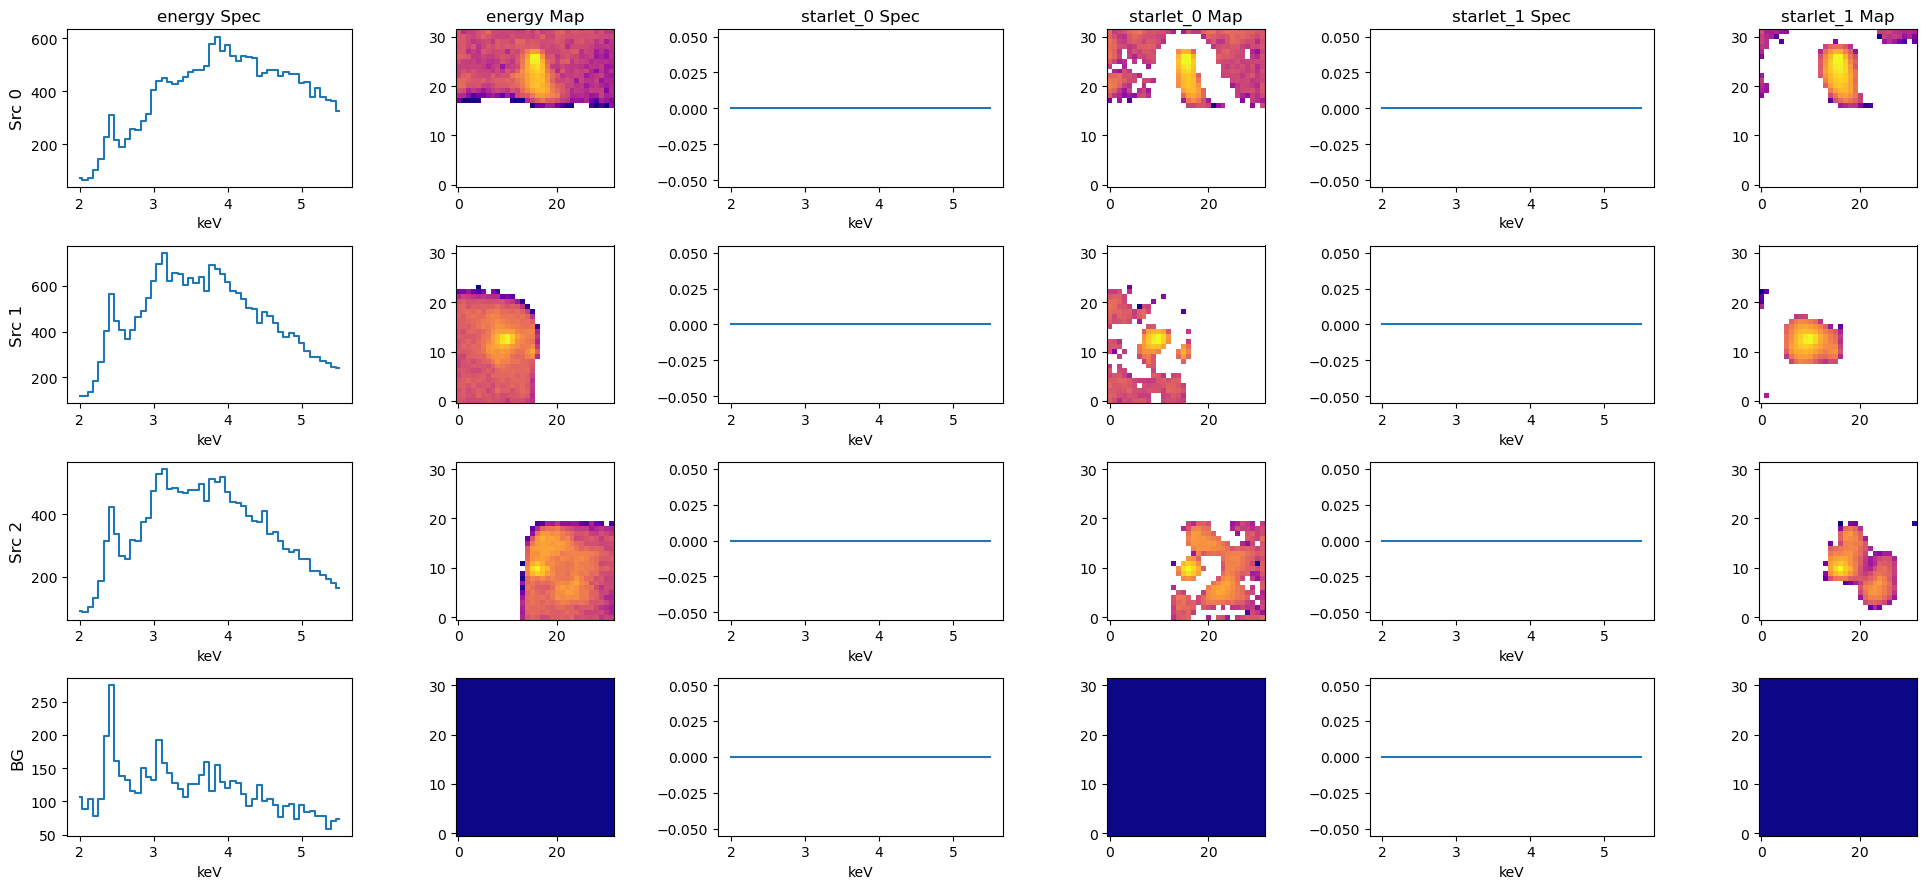

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import numpy as np

# Create the Energy x-axis based on your range and number of bins
energy_axis = np.linspace(EMIN/1.e3, EMAX/1.e3, BINE) 

fig, axes = plt.subplots(NCOMP + 1, (NUM_LVL+1) * 2, figsize=(10*NUM_LVL, 3*NCOMP))

for i in range(NCOMP + 1):
    for j in range(NUM_LVL+1):
        # Spectrum
        ax_spec = axes[i, j * 2]
        ax_spec.step(energy_axis, spec_hist[i, j, :], where='mid', color='C0', lw=1.5)
        
        if i == 0:
            ax_spec.set_title(f'{e_lvls[j]} Spec')
        if j == 0:
            row_label = f'Src {i}' if i < NCOMP else 'BG'
            ax_spec.set_ylabel(row_label, size=12)
        ax_spec.set_xlabel('keV')

        # Spatial Map
        ax_img = axes[i, j * 2 + 1]
        img_data = S_gmm[i, j]
        ax_img.imshow(img_data.T, origin='lower', cmap='plasma', norm=LogNorm())
        
        if i == 0:
            ax_img.set_title(f'{e_lvls[j]} Map')

plt.tight_layout()
plt.show()

In [86]:
# ADD BLANKSKY TO SPECTRAL SOURCES
NCOMP_TRUE = NCOMP + 1
spec_hist = np.zeros((NCOMP_TRUE, n_bands))
bg_hist, edges = np.histogram(bg_subset['energy'], bins=n_bands, range=(EMIN, EMAX))
bg_hist = gaussian_filter1d((bg_hist),0.5)
bg_hist = torch.tensor(0.5 * bg_hist)

for i in range(NCOMP):
    mask = probs[:, i] > 0.5
    spec_hist[i], _ = np.histogram(
        subset[mask]['energy'],
        bins=n_bands,
        range=(EMIN, EMAX),
        weights=probs[mask][:, i]
    )

# normalization magic (maintain different maximums)
spec_hist = gaussian_filter1d(spec_hist, 0.5) # smooth out spectra a lil
max_spec = np.max(spec_hist) # take max of the spectra
spec_hist = torch.from_numpy(spec_hist)
spec_hist[i + 1] = bg_hist
spec_hist = spec_hist / (2 * max_spec)

## PYTORCH ##

/tmp/ipykernel_29224/2710057047.py:23: UserWarning: Adding colorbar to a different Figure <Figure size 500x200 with 3 Axes> than <Figure size 800x200 with 2 Axes> which fig.colorbar is called on.
  fig.colorbar(h2d[3], ax=ax)
/tmp/ipykernel_29224/2710057047.py:23: UserWarning: Adding colorbar to a different Figure <Figure size 500x200 with 3 Axes> than <Figure size 800x200 with 4 Axes> which fig.colorbar is called on.
  fig.colorbar(h2d[3], ax=ax)
/tmp/ipykernel_29224/2710057047.py:23: UserWarning: Adding colorbar to a different Figure <Figure size 500x200 with 3 Axes> than <Figure size 800x200 with 6 Axes> which fig.colorbar is called on.
  fig.colorbar(h2d[3], ax=ax)
/tmp/ipykernel_29224/2710057047.py:23: UserWarning: Adding colorbar to a different Figure <Figure size 500x200 with 3 Axes> than <Figure size 800x200 with 8 Axes> which fig.colorbar is called on.
  fig.colorbar(h2d[3], ax=ax)


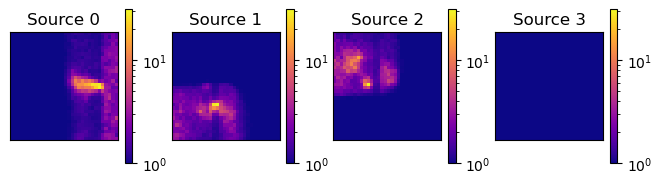

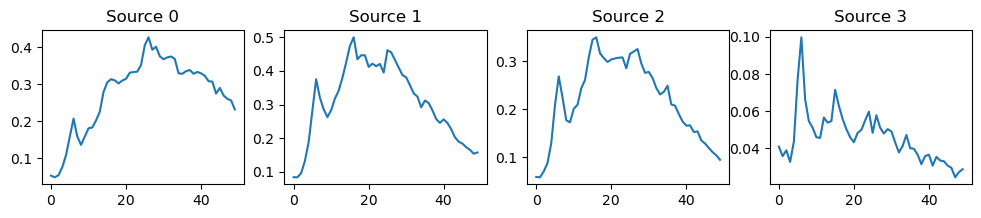

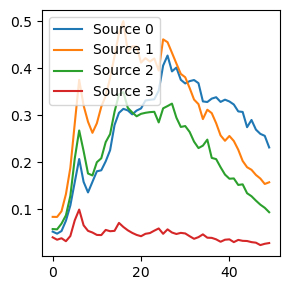

In [87]:
from tqdm import tqdm

# INITIALIZATIONS + PLOTTING
# Initialize A and S with the GMM clusters
# we redeclare these in the Pytorch function cell

#S
S = torch.nn.functional.normalize(torch.from_numpy(S_gmm), dim=(0,1)).requires_grad_().to(device) # initialize S with normalization

# A
A = spec_hist.T.requires_grad_().to(device)

# plotting check

# spatial plots
fig = plt.figure(figsize=(2*NCOMP_TRUE, 2))
for i, source in enumerate(S.detach().numpy()):
    ax = plt.subplot(100 + 10*NCOMP_TRUE + i + 1)
    ax.imshow(source, origin="lower", cmap="plasma")
    ax.set_title(f'Source {i}')
    ax.xaxis.set_visible(False)
    ax.yaxis.set_visible(False)
    fig.colorbar(h2d[3], ax=ax)

# individual spectra plots
fig = plt.figure(figsize=(3*NCOMP_TRUE, 2))
for i, source in enumerate(A.T.detach().numpy()):
    ax = plt.subplot(100 + 10*NCOMP_TRUE + i + 1)
    ax.plot(source)
    ax.set_title(f'Source {i}')

# combined spectra plot
plt.figure(figsize=(NCOMP, 3))
for i in range(4):
    plt.plot(A.detach().numpy()[:,i], label=f'Source {i}')

plt.legend()
plt.tight_layout()


## Loss Functions ##

In [88]:
import pywt

def my_loss_function_F(model, target):
    mse_loss = torch.mean((model - target)**2)
    return mse_loss

def my_loss_function_poisson(model, target):
    # Assuming model and target are tensors
    model_copy = model.clone()
    model_copy[model == 0] = 1.e-10
    return torch.sum(model_copy - target * torch.log(model_copy))   # Poisson loss

## Image smoothness [i.e, lp norm on the gradient]
def image_variation_loss(x: torch.Tensor) -> torch.Tensor:
    tv_h = torch.sum(torch.abs(x[1:, :] - x[:-1, :]))
    tv_w = torch.sum(torch.abs(x[:, 1:] - x[:, :-1]))
    return tv_h + tv_w

## Spectral smoothness [i.e, lp norm on the gradient]
def spectral_variation_loss(x: torch.Tensor) -> torch.Tensor:
    tv_h = torch.sum(torch.abs(x[1:] - x[:-1]))
    return tv_h


def sparsity(x: torch.Tensor) -> torch.Tensor:
    return torch.sum(torch.abs(x)) # L1 norm

# p = 1 --> close to Laplacean, more blocky, allows more outliers
# p = 2 --> close to Gaussian, more smooth and wave-like
# Google explanation of lp-norms for more
def lp_norm(x, p=1) -> torch.Tensor:
    assert p >= 1
    assert p <= 2
    return torch.sum(torch.abs(x + 1.e-8)**p)**(1/p)

## Image smoothness [i.e, lp norm on the gradient]
scaled_spec = torch.softmax(spec_hist, dim=1)

def spectral_min_change(x: torch.Tensor) -> torch.Tensor:
    # for shape (H, W)
    tv_h = torch.sum(torch.abs(scaled_spec - x))
    return tv_h

def starlet_loss(cube: torch.Tensor) -> torch.Tensor:
    cube_np = cube.detach().cpu().numpy()
    coeffs = pys.Starlet_Forward3D(cube_np,J=4)[:,:,:,1:2]
    loss = np.sum(np.abs(coeffs))
    return loss

  0%|          | 0/2000 [00:00<?, ?it/s]

Step 0, Loss: 180725.6763
Loss Composition: 0.001206061844429983 starlet, 0.0014699470117262442
Magnitudes: A (3.5563737274253513), S (5.656854249492381)


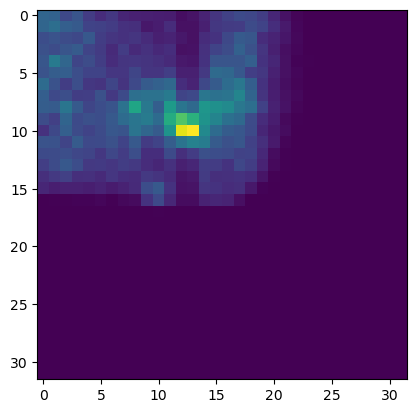

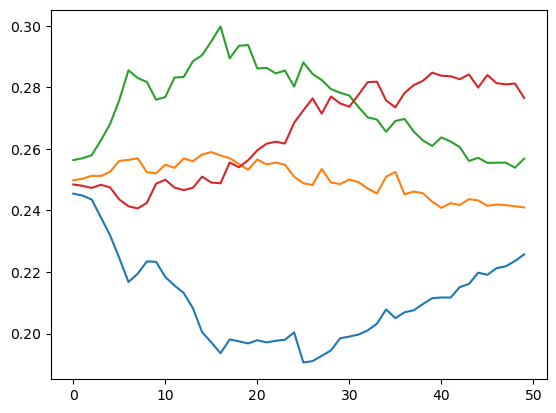

 25%|██▍       | 498/2000 [00:14<00:13, 111.34it/s]

Step 500, Loss: 88224.5951
Loss Composition: 0.0031141244375087977 starlet, 0.02204851848265208
Magnitudes: A (3.6825666503543406), S (16.52151186480014)


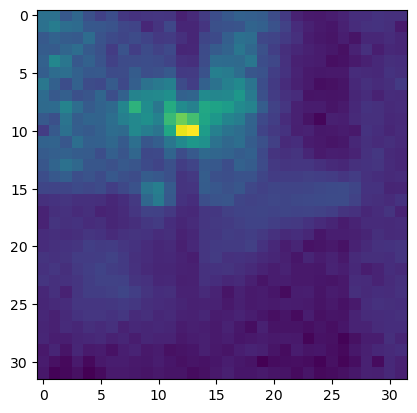

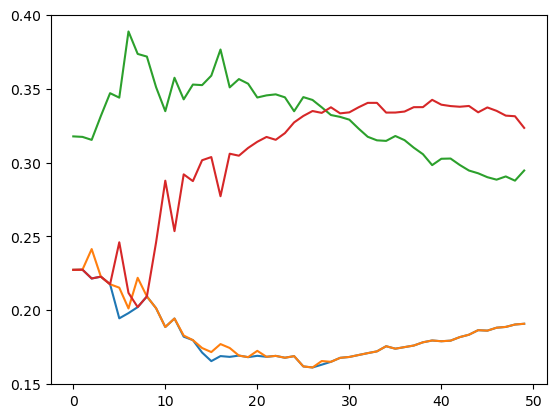

 50%|████▉     | 995/2000 [00:19<00:09, 107.40it/s]

Step 1000, Loss: 70282.3771
Loss Composition: 0.0041271601886401724 starlet, 0.044991052389048346
Magnitudes: A (3.8608292429952753), S (23.731567334545872)


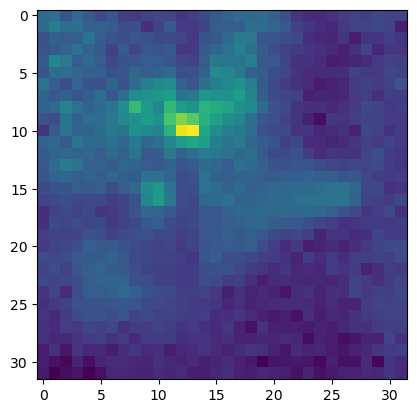

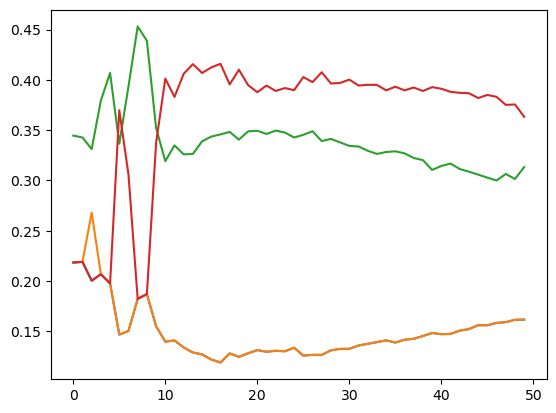

 75%|███████▍  | 1498/2000 [00:24<00:05, 92.85it/s] 

Step 1500, Loss: 59604.3599
Loss Composition: 0.004669702527436037 starlet, 0.059438820069072175
Magnitudes: A (4.198061989966527), S (29.11142762585491)


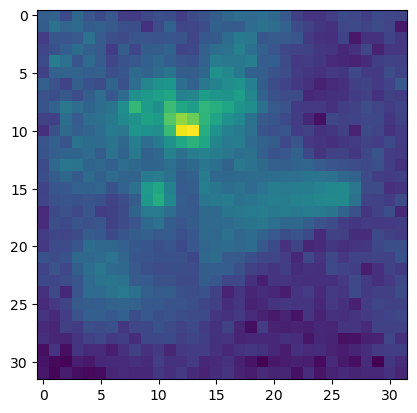

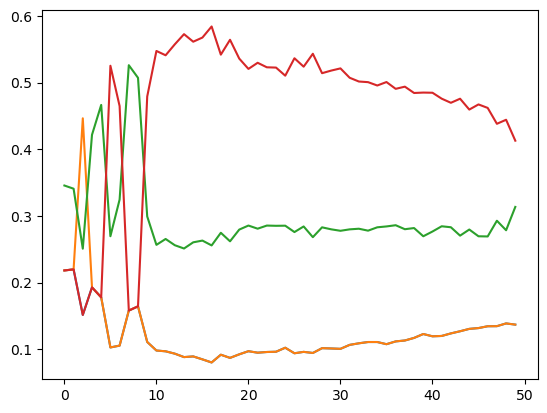

100%|██████████| 2000/2000 [00:30<00:00, 65.97it/s] 


In [89]:
S = torch.nn.functional.normalize(torch.from_numpy(S_gmm), dim=(0,1)).requires_grad_().to(device) # initialize S with normalization
A = spec_hist.T.requires_grad_().to(device)

lr = 8.e-4
optimizer = torch.optim.Adam([S, A], lr=lr)

# initialize loss values for plot
loss_values = []

max_iter = 2000
lambda_smooth = 1.
lambda_spec = 2.
lambda_sparsity = 10.
lambda_starlet = 2.
gamma = 10000


for i in tqdm(range(max_iter)):
        A_pos = torch.clamp(A, min=0)  # non-negativity
        A_pos = torch.softmax(A_pos, dim=1)  # sum-to-one constraint
        S_pos = torch.clamp(S, min=0)    # non-negativity

        reconstruction = torch.einsum('bc,cxy->bxy', A_pos, S_pos) # TODO: learn einsum shorthand
    
        # Try poisson loss function
        loss = my_loss_function_poisson(reconstruction, spectral_cube_tensor.to(device))
        
        star_loss = 0
        overlap_loss = 0
        for j in range(n_comp):
            component_j = torch.einsum('c,xy->cxy', A_pos[:, j], S_pos[j])
            star_loss = starlet_loss(component_j)
            
            #loss += sparsity(S_pos[j,:,:]) * lambda_sparsity  # encourage sparsity
            #loss += image_variation_loss(S_pos[j, :, :]) * lambda_smooth
            
            # spectral smoothness (maybe unnecessary)
            #loss += spectral_min_change(A_pos[:,j]) * lambda_spec
            
            # cross-source spatial sparsity
            for ij in range(j + 1, n_comp):
                overlap_loss += torch.sum(S_pos[ij] * S_pos[ij])
        loss += star_loss * lambda_starlet     
        loss += lambda_sparsity * overlap_loss
        
        loss.backward()
        
        optimizer.step()
        optimizer.zero_grad()
        if i % 500 == 0:
            print(f"Step {i}, Loss: {loss.item():.4f}")
            print(f"Loss Composition: {lambda_starlet * star_loss / loss} starlet, {lambda_sparsity * overlap_loss / loss}")
            print(f"Magnitudes: A ({torch.norm(A_pos)}), S ({torch.norm(S_pos)})")
            loss_values.append(loss.item())

            plt.imshow(S_pos.detach().cpu().numpy()[1,:,:,])
            plt.show()
            plt.plot(A_pos.detach().cpu().numpy()[:,3], label=f'3')
            plt.plot(A_pos.detach().cpu().numpy()[:,2], label=f'2')
            plt.plot(A_pos.detach().cpu().numpy()[:,1], label=f'1')
            plt.plot(A_pos.detach().cpu().numpy()[:,0], label=f'0')
            plt.show()